In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
noisy_data = pd.read_csv("~/python_decal_fa25/course_assignments/homework9/noisy_curvefit_data.csv")
noisy_data

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113
...,...,...,...,...,...,...
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548


In [4]:
print(noisy_data.shape) 

# The shape of the data is (100,6)

# The DataFrame has 100 rows and 6 columns

(100, 6)


In [5]:
noisy_data.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [6]:
noisy_data.tail()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


In [7]:
# The column names are x, and y_noise_[1-5]

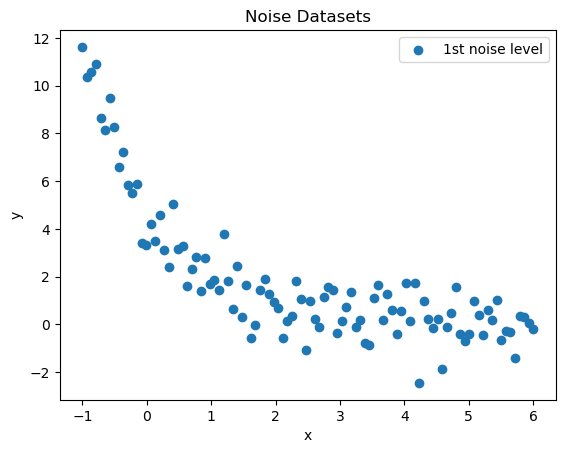

In [8]:
plt.figure()

plt.scatter(noisy_data['x'], noisy_data['y_noise_1'], label="1st noise level")

plt.title("Noise Datasets")
plt.ylabel("y")
plt.xlabel("x")

plt.legend()

plt.show()

In [9]:
def model(x,A,k):
    return A*np.exp(-k*x)

p0 = [1,1]
popt, pcov = curve_fit(model, noisy_data['x'], noisy_data['y_noise_1'], p0=p0)

A_fit, k_fit = popt

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f}*x)")

Fit: y = 4.71 * e^(-0.92*x)


In [10]:
residuals = noisy_data['y_noise_1'] - model(noisy_data['x'], A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(noisy_data['x']) - len(popt)
chi2_reduced  = chi2/dof

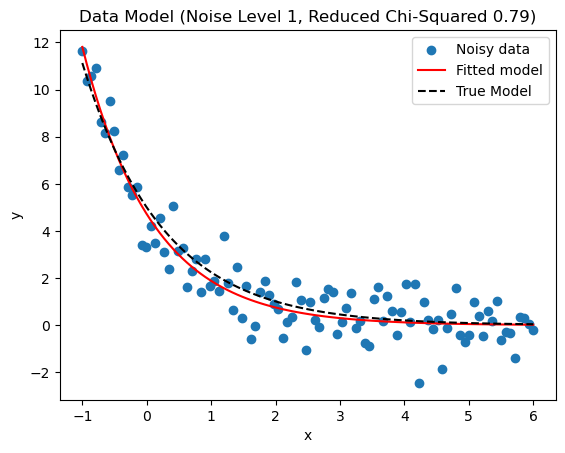

In [11]:
plt.figure()

plt.scatter(noisy_data['x'], noisy_data['y_noise_1'], label="Noisy data")

plt.plot(noisy_data['x'], model(noisy_data['x'], A_fit, k_fit), label="Fitted model", color='r')

plt.plot(noisy_data['x'], model(noisy_data['x'], 5, 0.8), label="True Model", color='black', linestyle='--')

plt.title(f"Data Model (Noise Level 1, Reduced Chi-Squared {chi2_reduced:.2f})")

plt.ylabel("y")

plt.xlabel("x")

plt.legend()

plt.show()

In [12]:
def fit_model(x,y):
    def model(x,A,k):
        return A*np.exp(-k*x)
    p0 = [1,1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced  = chi2/dof
    return model(x, A_fit, k_fit)

In [13]:
print(fit_model(noisy_data['x'], noisy_data['y_noise_2']))

0     10.512142
1      9.983031
2      9.480553
3      9.003365
4      8.550196
        ...    
95     0.077796
96     0.073880
97     0.070162
98     0.066630
99     0.063276
Name: x, Length: 100, dtype: float64


In [14]:
print(fit_model(noisy_data['x'], noisy_data['y_noise_3']))

0     13.394109
1     12.594668
2     11.842942
3     11.136084
4     10.471415
        ...    
95     0.038711
96     0.036401
97     0.034228
98     0.032185
99     0.030264
Name: x, Length: 100, dtype: float64


In [15]:
print(fit_model(noisy_data['x'], noisy_data['y_noise_4']))

0     11.860366
1     11.266925
2     10.703176
3     10.167636
4      9.658891
        ...    
95     0.090426
96     0.085901
97     0.081603
98     0.077520
99     0.073641
Name: x, Length: 100, dtype: float64


In [16]:
print(fit_model(noisy_data['x'], noisy_data['y_noise_5']))

0     9.905371
1     9.430365
2     8.978139
3     8.547598
4     8.137704
        ...   
95    0.092974
96    0.088515
97    0.084271
98    0.080229
99    0.076382
Name: x, Length: 100, dtype: float64


In [17]:
new_set = noisy_data[['y_noise_2', 'y_noise_3', 'y_noise_4','y_noise_5']]

new_set.columns

Index(['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')

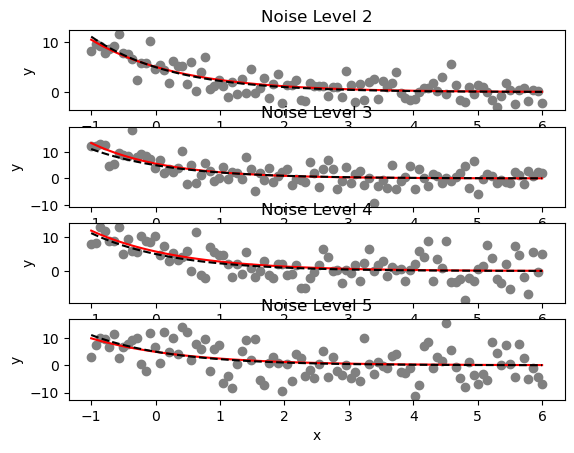

In [55]:
fig, ax = plt.subplots(4,1)
x = 0

for column in new_set.columns:
    ax[x].scatter(noisy_data['x'], noisy_data[column], label='noise', color='gray')
    ax[x].plot(noisy_data['x'], fit_model(noisy_data['x'], noisy_data[column]), label='Curve Fit', color='red')
    ax[x].plot(noisy_data['x'], model(noisy_data['x'], 5, 0.8), label='True Model', color='black', linestyle='--')
    ax[x].set_title(f"Noise Level {column[-1]}")
    ax[x].set_xlabel("x")
    ax[x].set_ylabel("y")
    # ax[x].legend()
    x+=1

plt.show()

# As you increase the noise level, the curve fit overestimates the true model

# The chi_squared increases with more noise because the curve fits less with the true model

In [71]:
new_new_set = noisy_data[['y_noise_1','y_noise_2', 'y_noise_3', 'y_noise_4','y_noise_5']]

def fit_model_parameters(x,y):
    def model(x,A,k):
        return A*np.exp(-k*x)
    p0 = [1,1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced  = chi2/dof
    return A_fit, k_fit

ultimate_dicti = []

for column in new_new_set:
    p0 = [1,1]
    A_fit = fit_model_parameters(noisy_data['x'], noisy_data[column])[0]
    k_fit = fit_model_parameters(noisy_data['x'], noisy_data[column])[1]
    residuals = noisy_data[column] - model(noisy_data['x'], A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(noisy_data['x']) - len(popt)
    chi2_reduced  = chi2/dof
    dicti = {'Noise Level': int(column[-1]), 'A_fit': A_fit, 'k_fit': k_fit, 'chi2reduced': chi2_reduced}
    ultimate_dicti.append(dicti)

# print(ultimate_dicti)

finally_done = pd.DataFrame(ultimate_dicti)

finally_done.to_csv('noisy_parameters.csv', index=False)